# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Child IQ Master Dataset](https://www.kaggle.com/datasets/sergionefedov/child-iq-genes-environment?select=child_iq_master.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('child_iq_master.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,child_id,child_sex,child_age_at_test,birth_year,birth_order,mother_iq,father_iq,parental_ses,maternal_education_years,household_income_bracket,two_parent_household,maternal_age_at_birth,iodine_status,prenatal_care,maternal_smoking_pregnancy,alcohol_exposure,gestational_age_weeks,preterm,birth_weight_g,low_birth_weight,breastfed_months,lead_exposure,home_stimulation_score,early_education,books_in_home,screen_hours_daily,nutrition_quality,adverse_childhood_experiences,child_iq,high_cognitive_potential
0,CHD000000,F,7,2018,3,87,107,40.8,16,middle,1,36,deficient,regular,0,0,39,0,3188,0,6,low,30,quality_preschool,61,3.3,6.9,2,95,0
1,CHD000001,M,12,2005,1,127,136,64.3,16,middle,1,31,adequate,regular,0,0,42,0,3897,0,14,low,51,quality_preschool,184,1.1,4.1,0,125,1
2,CHD000002,M,12,2020,3,112,92,39.8,11,low,1,38,mild_low,regular,0,0,40,0,3979,0,9,moderate,61,quality_preschool,43,0.6,6.7,0,123,1
3,CHD000003,M,11,2011,3,98,102,55.4,17,high,0,27,deficient,regular,0,0,40,0,3752,0,12,moderate,15,some_preschool,44,3.7,3.7,0,82,0
4,CHD000004,F,11,2016,2,113,116,45.8,19,middle,1,41,adequate,regular,0,0,38,0,2996,0,4,moderate,54,some_preschool,77,2.8,5.6,4,111,0


## last Five row

In [4]:
df.tail()

,child_id,child_sex,child_age_at_test,birth_year,birth_order,mother_iq,father_iq,parental_ses,maternal_education_years,household_income_bracket,two_parent_household,maternal_age_at_birth,iodine_status,prenatal_care,maternal_smoking_pregnancy,alcohol_exposure,gestational_age_weeks,preterm,birth_weight_g,low_birth_weight,breastfed_months,lead_exposure,home_stimulation_score,early_education,books_in_home,screen_hours_daily,nutrition_quality,adverse_childhood_experiences,child_iq,high_cognitive_potential
49995,CHD049995,F,7,2013,1,88,87,31.7,11,low,1,26,adequate,none,0,0,42,0,3108,0,2,elevated,14,quality_preschool,29,3.1,6.4,0,83,0
49996,CHD049996,M,9,2008,4,127,112,60.2,14,middle,1,29,mild_low,some,0,0,40,0,4708,0,3,moderate,71,some_preschool,74,0.0,2.4,2,98,0
49997,CHD049997,M,12,2011,2,73,98,54.6,7,middle,0,25,adequate,some,1,0,39,0,3531,0,4,moderate,50,some_preschool,158,0.6,3.6,2,97,0
49998,CHD049998,M,8,2006,2,82,90,33.5,11,very_low,1,29,adequate,some,0,0,40,0,2206,1,14,moderate,35,some_preschool,69,3.5,4.9,2,90,0
49999,CHD049999,F,6,2017,2,99,107,65.8,11,high,1,36,adequate,regular,0,0,35,1,2752,0,0,low,39,none,39,3.9,6.2,2,111,0


## Shape of our dataset

In [5]:
df.shape

(50000, 30)

## List out all columns

In [6]:
df.columns

Index(['child_id', 'child_sex', 'child_age_at_test', 'birth_year',
       'birth_order', 'mother_iq', 'father_iq', 'parental_ses',
       'maternal_education_years', 'household_income_bracket',
       'two_parent_household', 'maternal_age_at_birth', 'iodine_status',
       'prenatal_care', 'maternal_smoking_pregnancy', 'alcohol_exposure',
       'gestational_age_weeks', 'preterm', 'birth_weight_g',
       'low_birth_weight', 'breastfed_months', 'lead_exposure',
       'home_stimulation_score', 'early_education', 'books_in_home',
       'screen_hours_daily', 'nutrition_quality',
       'adverse_childhood_experiences', 'child_iq',
       'high_cognitive_potential'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

child_id                          object
child_sex                         object
child_age_at_test                  int64
birth_year                         int64
birth_order                        int64
mother_iq                          int64
father_iq                          int64
parental_ses                     float64
maternal_education_years           int64
household_income_bracket          object
two_parent_household               int64
maternal_age_at_birth              int64
iodine_status                     object
prenatal_care                     object
maternal_smoking_pregnancy         int64
alcohol_exposure                   int64
gestational_age_weeks              int64
preterm                            int64
birth_weight_g                     int64
low_birth_weight                   int64
breastfed_months                   int64
lead_exposure                     object
home_stimulation_score             int64
early_education                   object
books_in_home   

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   child_id                       50000 non-null  object 
 1   child_sex                      50000 non-null  object 
 2   child_age_at_test              50000 non-null  int64  
 3   birth_year                     50000 non-null  int64  
 4   birth_order                    50000 non-null  int64  
 5   mother_iq                      50000 non-null  int64  
 6   father_iq                      50000 non-null  int64  
 7   parental_ses                   50000 non-null  float64
 8   maternal_education_years       50000 non-null  int64  
 9   household_income_bracket       50000 non-null  object 
 10  two_parent_household           50000 non-null  int64  
 11  maternal_age_at_birth          50000 non-null  int64  
 12  iodine_status                  50000 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

child_id                         0
child_sex                        0
child_age_at_test                0
birth_year                       0
birth_order                      0
mother_iq                        0
father_iq                        0
parental_ses                     0
maternal_education_years         0
household_income_bracket         0
two_parent_household             0
maternal_age_at_birth            0
iodine_status                    0
prenatal_care                    0
maternal_smoking_pregnancy       0
alcohol_exposure                 0
gestational_age_weeks            0
preterm                          0
birth_weight_g                   0
low_birth_weight                 0
breastfed_months                 0
lead_exposure                    0
home_stimulation_score           0
early_education                  0
books_in_home                    0
screen_hours_daily               0
nutrition_quality                0
adverse_childhood_experiences    0
child_iq            

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,child_age_at_test,birth_year,birth_order,mother_iq,father_iq,parental_ses,maternal_education_years,two_parent_household,maternal_age_at_birth,maternal_smoking_pregnancy,alcohol_exposure,gestational_age_weeks,preterm,birth_weight_g,low_birth_weight,breastfed_months,home_stimulation_score,books_in_home,screen_hours_daily,nutrition_quality,adverse_childhood_experiences,child_iq,high_cognitive_potential
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,9.00612,2012.511800,1.915480,99.966520,100.06634,49.980570,13.032180,0.680920,28.993700,0.116640,0.061120,38.95490,0.105520,3360.03920,0.054780,6.00734,50.094560,79.895860,2.635496,5.985378,1.599900,99.99824,0.104780
std,1.99899,4.616341,0.952195,14.933566,14.96111,18.270037,3.238005,0.466125,5.482844,0.320994,0.239553,1.91067,0.307225,533.64906,0.227553,4.18793,15.917797,59.322402,1.453614,2.014441,1.313474,11.52333,0.306273
min,6.00000,2005.000000,1.000000,55.000000,55.00000,1.000000,6.000000,0.000000,15.000000,0.000000,0.000000,31.00000,0.000000,1035.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,53.00000,0.000000
25%,7.00000,2008.000000,1.000000,90.000000,90.00000,37.500000,11.000000,0.000000,25.000000,0.000000,0.000000,38.00000,0.000000,3004.75000,0.000000,3.00000,39.000000,37.000000,1.600000,4.600000,1.000000,92.00000,0.000000
50%,9.00000,2013.000000,2.000000,100.000000,100.00000,50.000000,13.000000,1.000000,29.000000,0.000000,0.000000,39.00000,0.000000,3359.00000,0.000000,5.00000,50.000000,66.000000,2.600000,6.000000,1.000000,100.00000,0.000000
75%,11.00000,2017.000000,3.000000,110.000000,110.00000,62.400000,15.000000,1.000000,33.000000,0.000000,0.000000,40.00000,0.000000,3722.00000,0.000000,8.00000,61.000000,107.000000,3.600000,7.400000,2.000000,108.00000,0.000000
max,12.00000,2020.000000,4.000000,160.000000,160.00000,99.000000,22.000000,1.000000,48.000000,1.000000,1.000000,42.00000,1.000000,5200.00000,1.000000,24.00000,100.000000,600.000000,9.500000,10.000000,9.000000,152.00000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

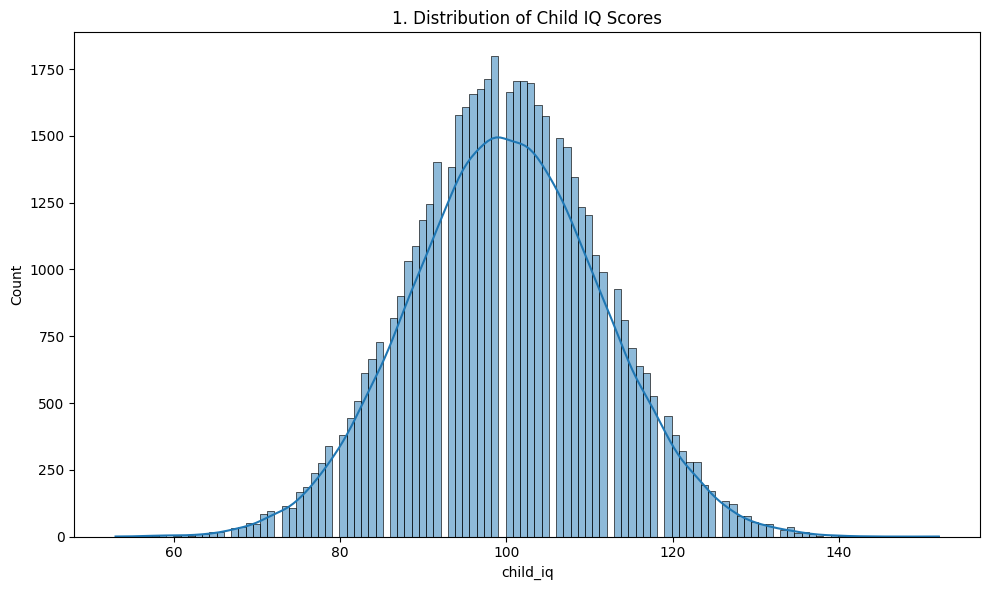

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['child_iq'], kde=True)
plt.title(f'{plot_no}. Distribution of Child IQ Scores')
show_fig()
plot_no += 1

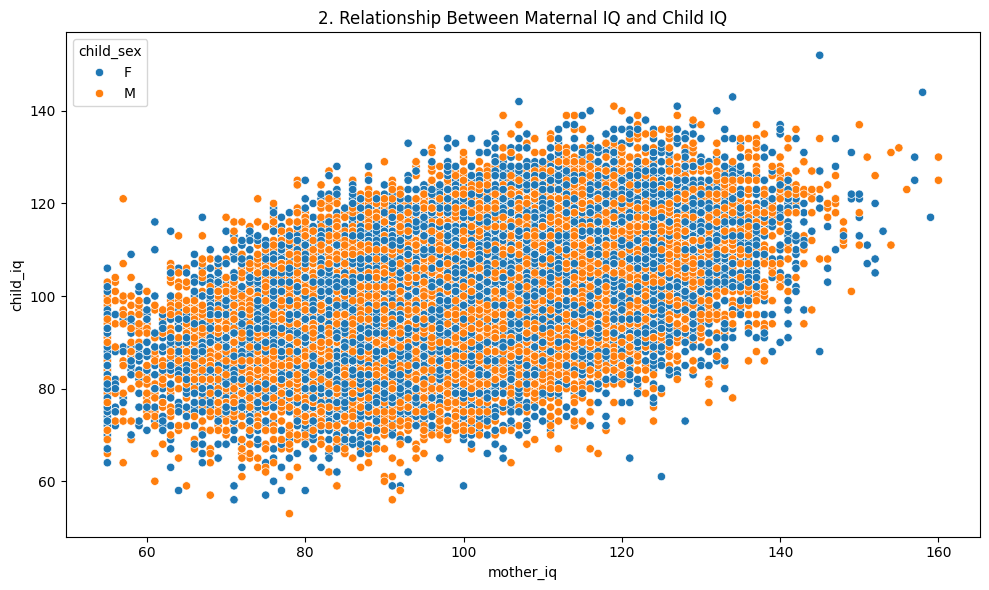

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='mother_iq', y='child_iq', hue='child_sex')
plt.title(f'{plot_no}. Relationship Between Maternal IQ and Child IQ')
show_fig()
plot_no += 1

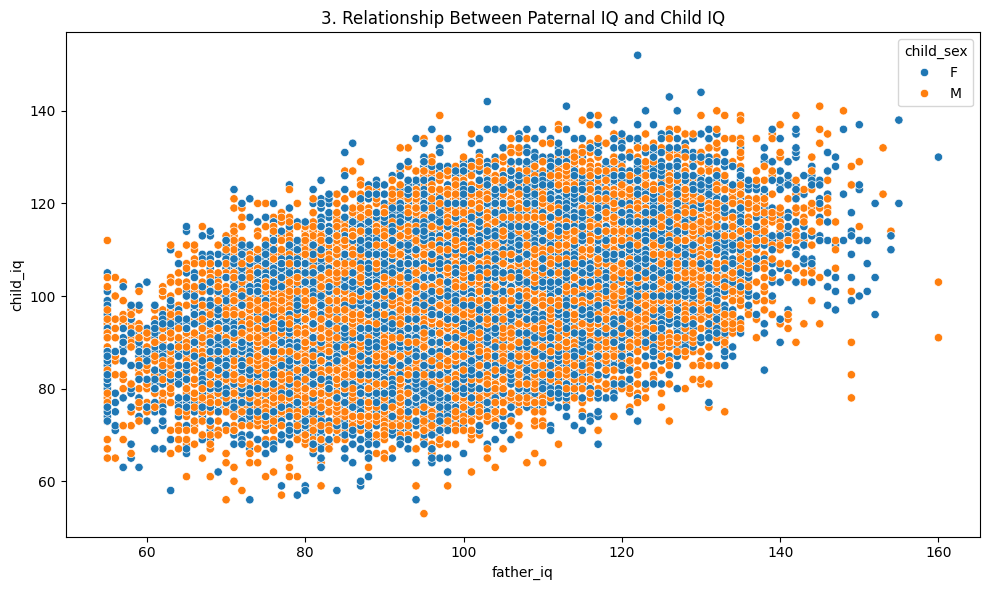

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='father_iq', y='child_iq', hue='child_sex')
plt.title(f'{plot_no}. Relationship Between Paternal IQ and Child IQ')
show_fig()
plot_no += 1

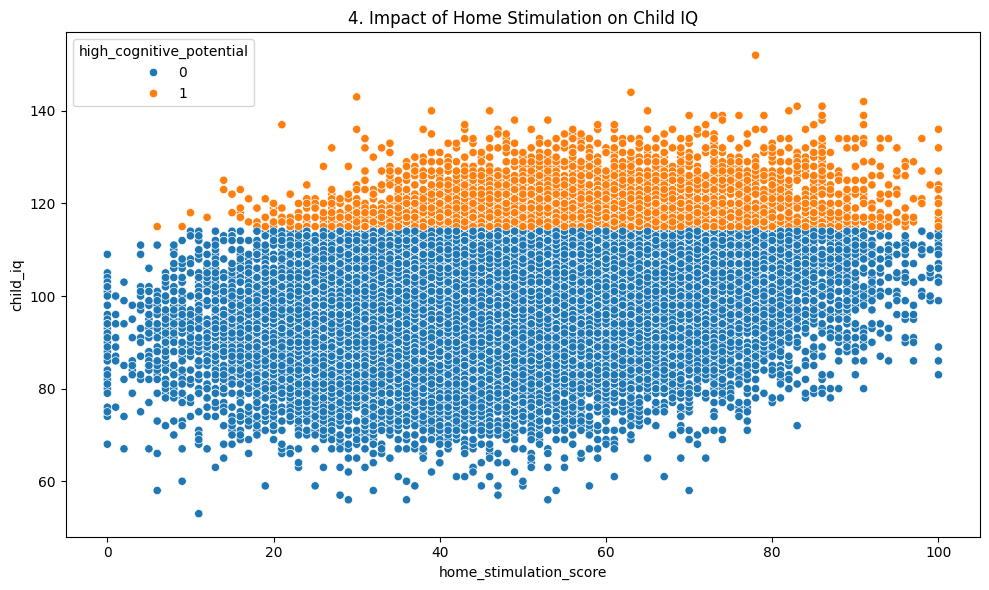

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='home_stimulation_score', y='child_iq', hue='high_cognitive_potential')
plt.title(f'{plot_no}. Impact of Home Stimulation on Child IQ')
show_fig()
plot_no += 1

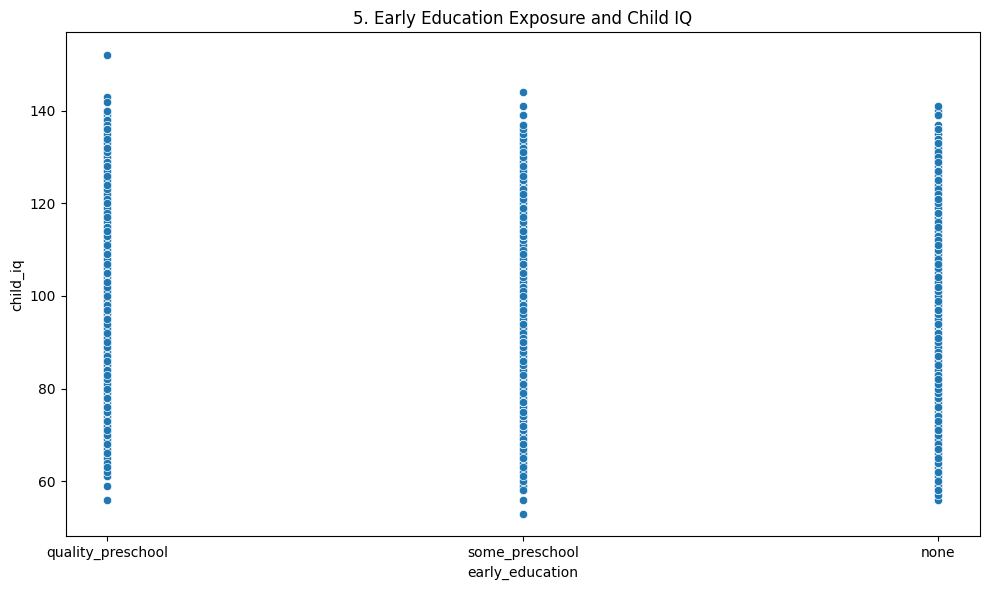

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='early_education', y='child_iq')
plt.title(f'{plot_no}. Early Education Exposure and Child IQ')
show_fig()
plot_no += 1

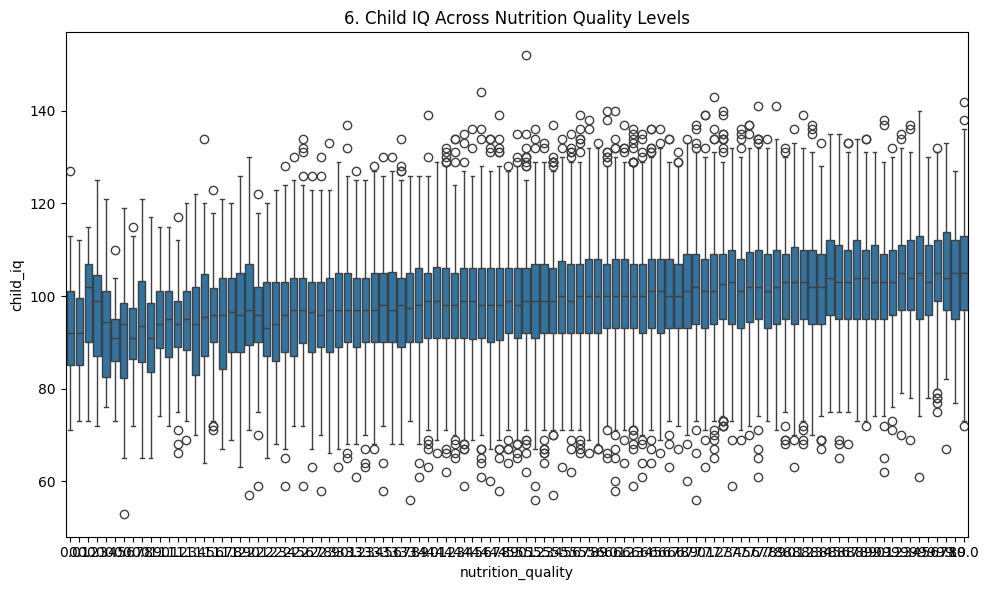

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='nutrition_quality', y='child_iq')
plt.title(f'{plot_no}. Child IQ Across Nutrition Quality Levels')
show_fig()
plot_no += 1

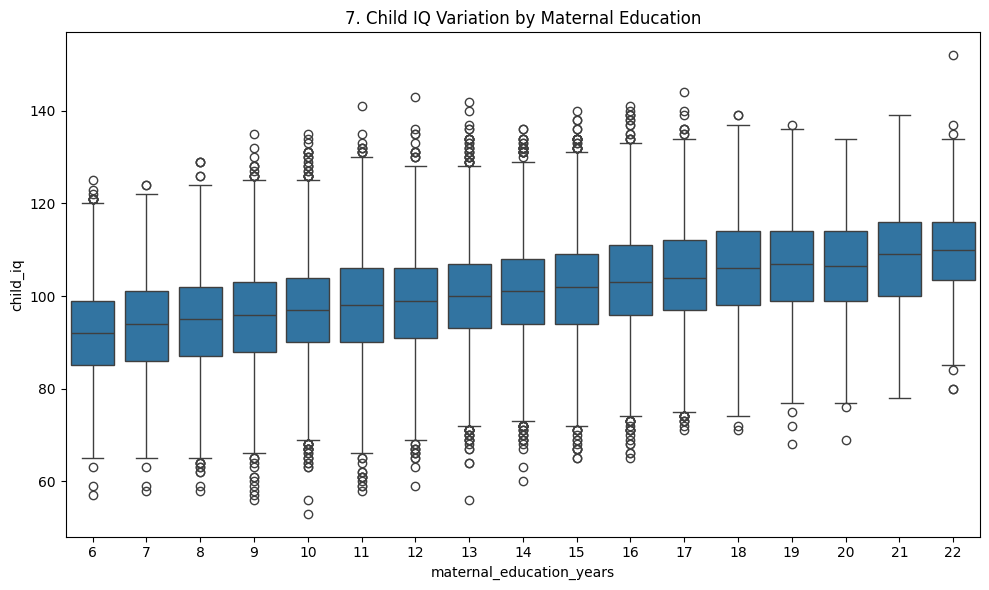

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='maternal_education_years', y='child_iq')
plt.title(f'{plot_no}. Child IQ Variation by Maternal Education')
show_fig()
plot_no += 1

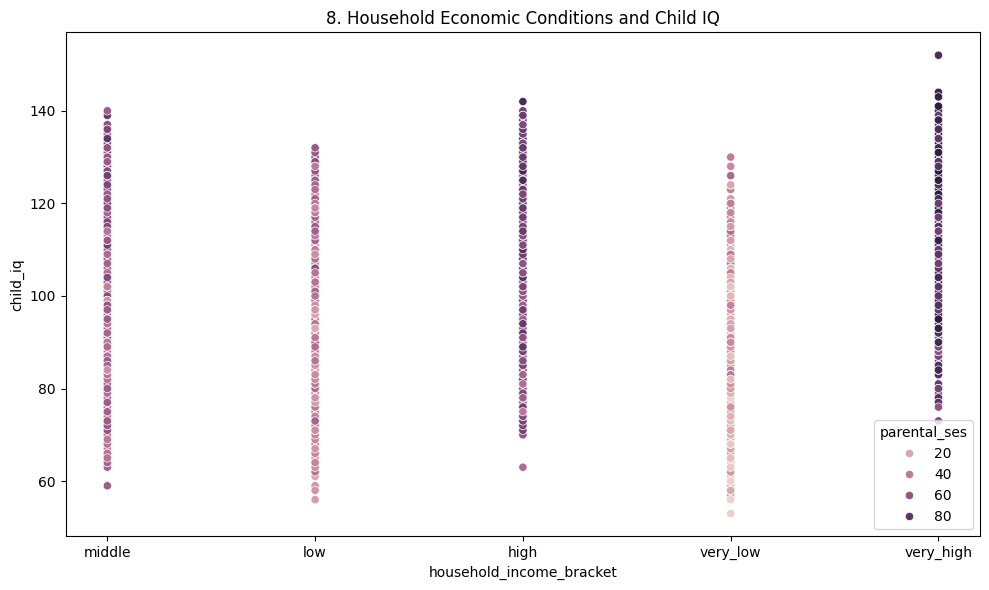

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='household_income_bracket', y='child_iq', hue='parental_ses')
plt.title(f'{plot_no}. Household Economic Conditions and Child IQ')
show_fig()
plot_no += 1

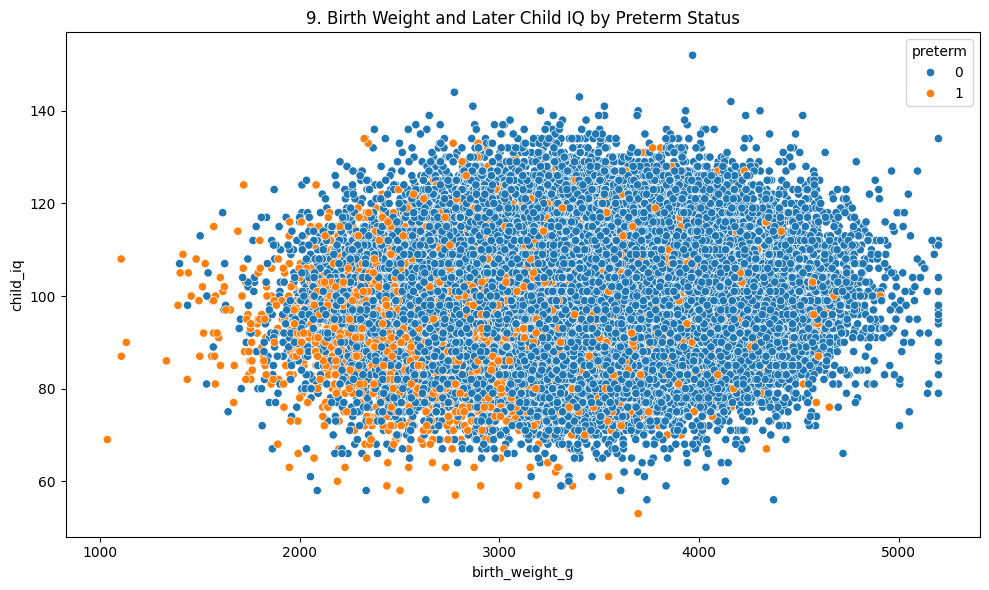

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='birth_weight_g', y='child_iq', hue='preterm')
plt.title(f'{plot_no}. Birth Weight and Later Child IQ by Preterm Status')
show_fig()
plot_no += 1

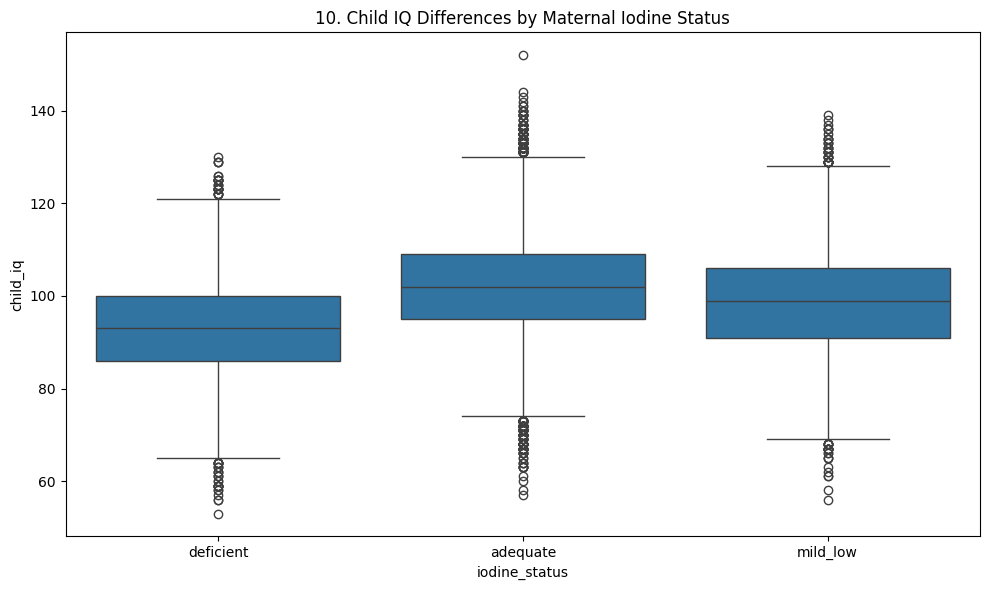

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='iodine_status', y='child_iq')
plt.title(f'{plot_no}. Child IQ Differences by Maternal Iodine Status')
show_fig()
plot_no += 1

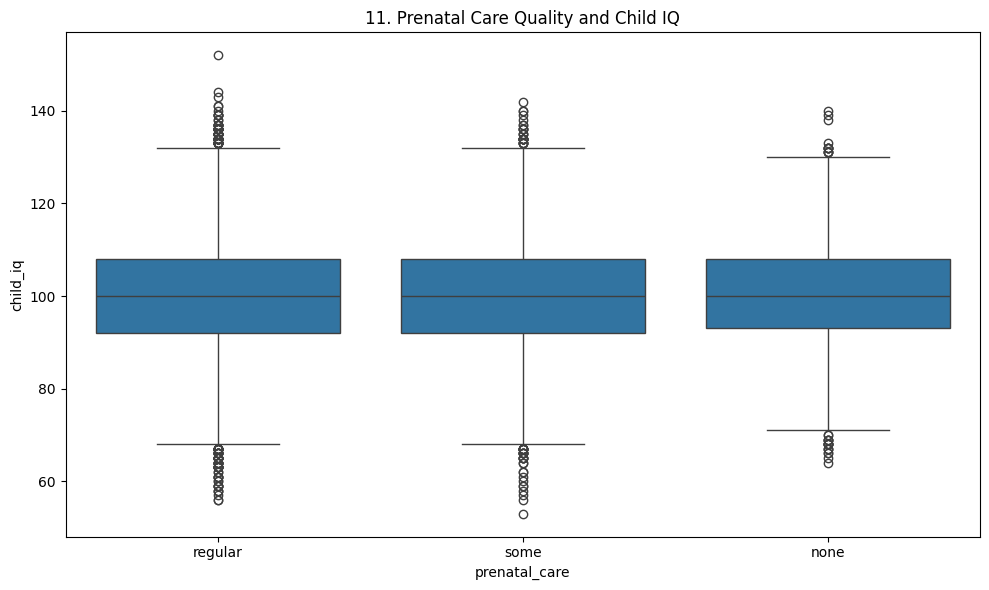

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='prenatal_care', y='child_iq')
plt.title(f'{plot_no}. Prenatal Care Quality and Child IQ')
show_fig()
plot_no += 1

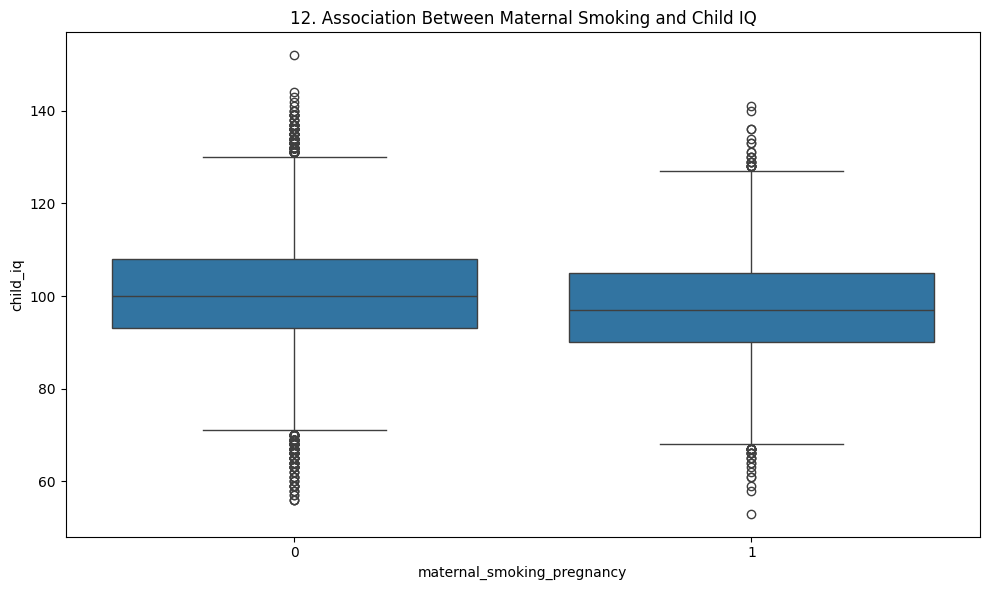

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='maternal_smoking_pregnancy', y='child_iq')
plt.title(f'{plot_no}. Association Between Maternal Smoking and Child IQ')
show_fig()
plot_no += 1

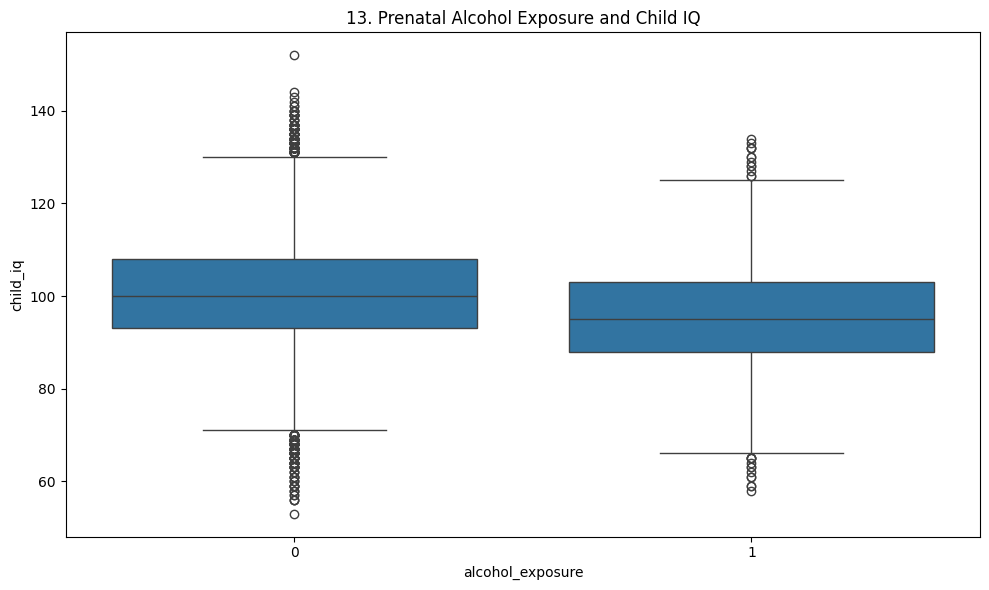

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='alcohol_exposure', y='child_iq')
plt.title(f'{plot_no}. Prenatal Alcohol Exposure and Child IQ')
show_fig()
plot_no += 1

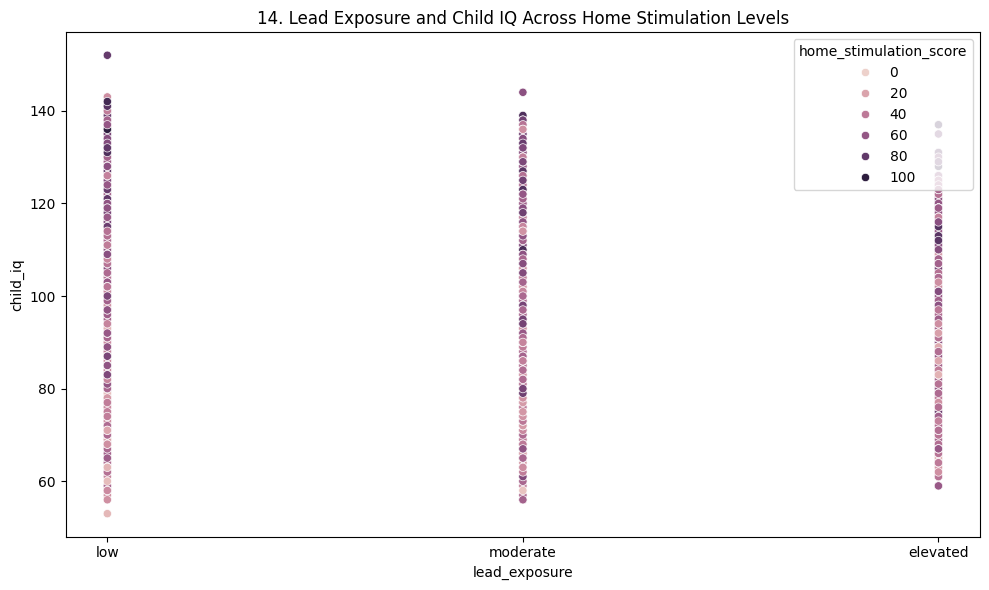

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='lead_exposure', y='child_iq', hue='home_stimulation_score')
plt.title(f'{plot_no}. Lead Exposure and Child IQ Across Home Stimulation Levels')
show_fig()
plot_no += 1

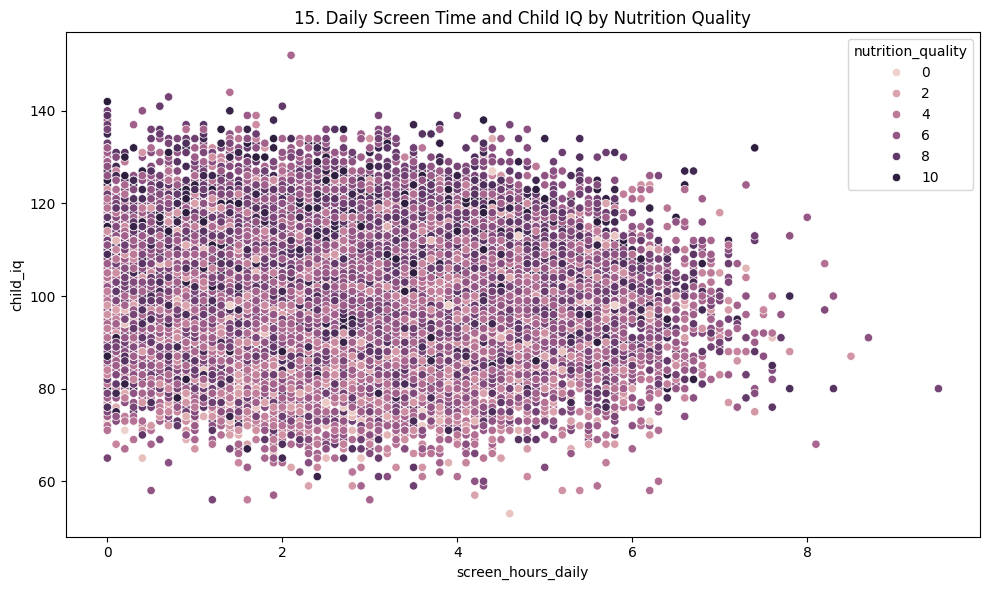

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='screen_hours_daily', y='child_iq', hue='nutrition_quality')
plt.title(f'{plot_no}. Daily Screen Time and Child IQ by Nutrition Quality')
show_fig()
plot_no += 1

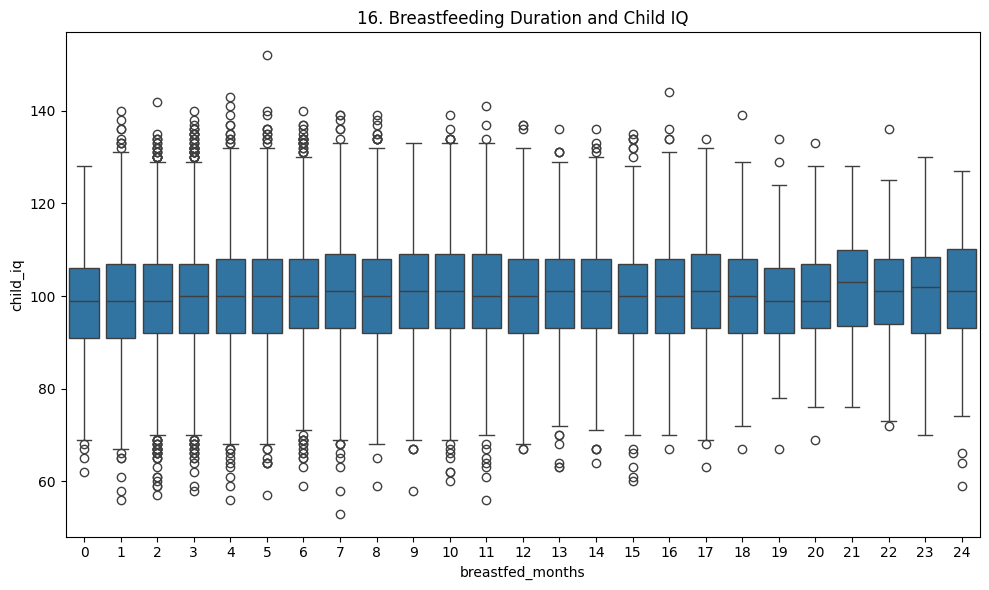

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='breastfed_months', y='child_iq')
plt.title(f'{plot_no}. Breastfeeding Duration and Child IQ')
show_fig()
plot_no += 1

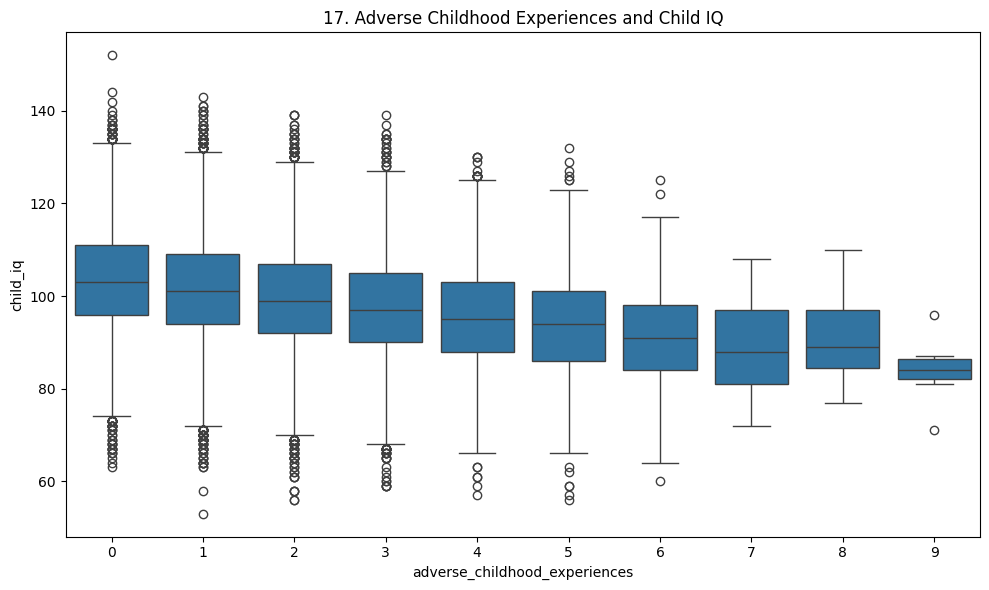

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='adverse_childhood_experiences', y='child_iq')
plt.title(f'{plot_no}. Adverse Childhood Experiences and Child IQ')
show_fig()
plot_no += 1

<Figure size 1500x900 with 0 Axes>

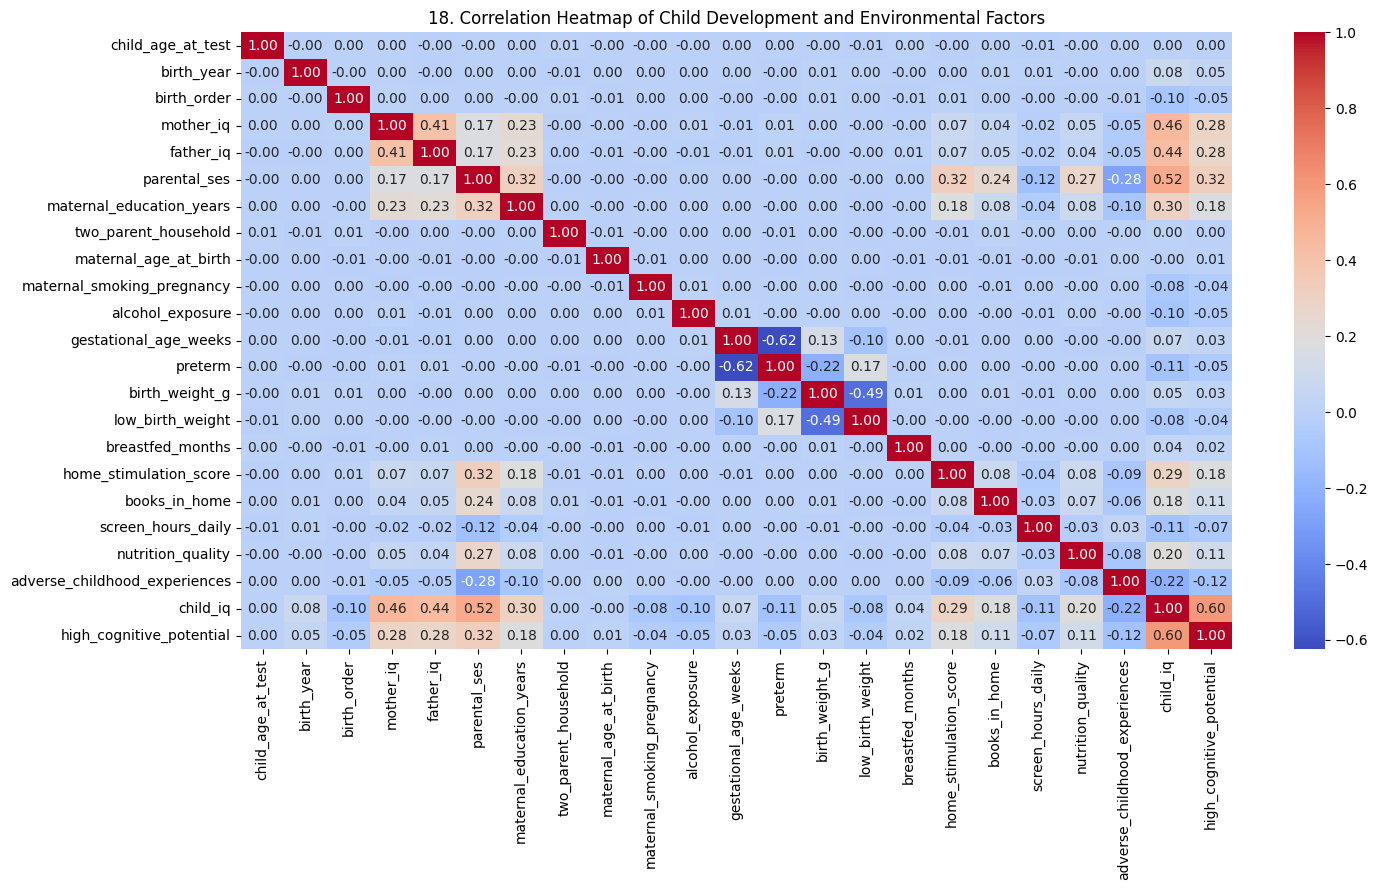

In [30]:
fig = plt.figure(figsize=(15, 9))
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Child Development and Environmental Factors')
show_fig()
plot_no += 1

# Model Training

## Prepare features and target

In [31]:
X = df.drop(columns=['child_iq', 'high_cognitive_potential', 'child_id'], errors='ignore')
y = df['high_cognitive_potential']

## Convert categorical columns into numerical features

In [32]:
X = pd.get_dummies(X, drop_first=True)

## Split data into training and testing sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Train Gradient Boosting model with scaling

In [34]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', GradientBoostingClassifier(random_state=42))])

## Make predictions

In [35]:
y_pred = model.predict(X_test)

## Print model accuracy

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 0.9170
Model Accuracy: 91.70%


## Print detailed classification results

In [37]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      8952
           1       0.69      0.38      0.49      1048

    accuracy                           0.92     10000
   macro avg       0.81      0.68      0.72     10000
weighted avg       0.91      0.92      0.91     10000



## Display confusion matrix

<Figure size 1000x600 with 0 Axes>

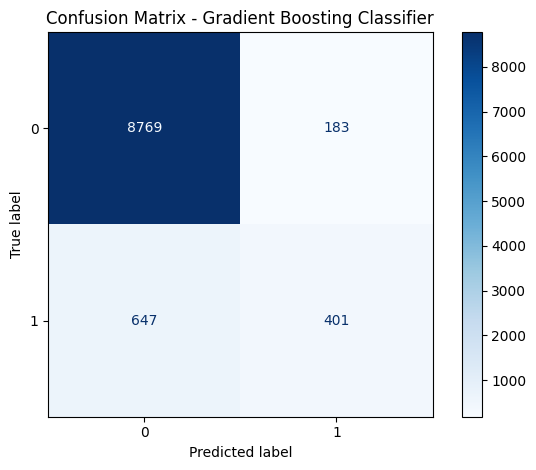

In [38]:
fig = plt.figure(figsize=(10, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.tight_layout()
plt.show()